## Ensemble forecast and verification exhibiting anomalous RPC ##

The following script defines a verification $Y$ drawn from a forecast distribution which is normal with mean $m(\pi)$ and a fixed standard deviation $\sin(\phi)$ where $\phi$ is prescribed. The mean $m(\pi)$ is again normal with mean zero and standard deviation $\cos(\phi)$. As a result, $Y$ has overall variance equal to one.

The forecast mean is defined as $m(f) = $ `Signal *` $ m(\pi)$ where `Signal` is prescribed.

### Prescribed quantities ###

$\cos(\phi) = r(m(\pi), Y)$ is the correlation between $m(\pi)$ and the verification $Y$ (equal to the correlation between $m(f)$ and the verification $Y$).

`Signal` defines $m(f)$ as $m(f) = $ `Signal *` $ m(\pi)$

`nr_timestamps` is the number of time stamps

`nr_ensemblemembers` is the number of ensemble members

### Derived analytic quantities ###

`Err` is the error between $m(f)$ and $Y$, that is $E((m(f) - Y)^2)$

$\cos(\psi) = r(m(f), Z)$ is the correlation between the mean $m(f)$ of $f$ and a draw $Z$ from $f$

$RPC = \cos(\phi)/ \cos(\psi)$

In [1]:
import numpy as np

In [2]:
nr_timestamps = 100
nr_ensemblemembers = 25
phi = 2 * np.pi * 0.15
Signal = 0.6
timestamps = np.arange(1, nr_timestamps)
M_pi = np.cos(phi) * np.random.normal(size=(nr_timestamps,1))
Y = M_pi + np.sin(phi) * np.random.normal(size=(nr_timestamps,1))
M_f = Signal * M_pi
Err = np.sqrt(1 + Signal**2 * np.cos(phi)**2 - 2 * Signal * np.cos(phi)**2)
var_M_f = (Signal**2)*(np.cos(phi)**2)
psi = np.arccos(np.sqrt(var_M_f / (Err**2 + var_M_f)))
ensemble = np.tile(M_f, (1, nr_ensemblemembers)) + Err * np.random.normal(size=(nr_timestamps,nr_ensemblemembers))
#Y = Y - Y.mean()
#ensemble = ensemble - ensemble.mean()

ensemble = np.load("ensemble.npy")
Y = np.load("Y.npy")

Quantities derived analytically:

In [3]:
print('Ensemble mean error (= ensemble std)', Err)
print('correlation between m(f) and Y', np.cos(phi))
print('correlation between m(f) and Z', np.cos(psi))
print('RPC: ', np.cos(phi)/ np.cos(psi))

Ensemble mean error (= ensemble std) 0.8424886572752645
correlation between m(f) and Y 0.5877852522924731
correlation between m(f) and Z 0.38613946779088143
RPC:  1.5222097229667169


In [4]:
m_f = np.mean(ensemble, 1).reshape(nr_timestamps, 1)
v_f = np.mean(np.var(ensemble, 1))
r_pi = np.mean(m_f * Y) / (np.std(m_f) * np.std(Y))
r_f = np.sqrt(np.var(m_f) / (v_f + np.var(m_f)))
err = np.sqrt(np.mean((Y - m_f)**2))

Quantities derived empirically:

In [5]:
print('Ensemble std', np.sqrt(v_f))
print('Ensemble mean error', err)
print('correlation between m(f) and Y', r_pi)
print('correlation between m(f) and Z', r_f)
print('RPC: ', r_pi / r_f)

Ensemble std 0.8339912398177479
Ensemble mean error 0.8861333718636012
correlation between m(f) and Y 0.6106816560778136
correlation between m(f) and Z 0.41153769756207614
RPC:  1.483902105919953


In [6]:
%run compute_snr.py

In [7]:
crps_samples = bootstrap(score_SSCrat, ensemble, Y.flatten(), 100, scoring_rule=scoringrules.crps_ensemble)

ERROR:2025-09-29 02:23:20,238:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/eviatar/miniconda3/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/eviatar/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/eviatar/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_UNKNOWN
100%|█████████████████████████████████████████| 100/100 [31:28<00:00, 18.88s/it]


In [22]:
score_SSCrat(ensemble, Y.flatten(), scoring_rule=scoringrules.crps_ensemble)

(np.float32(0.841113), np.float32(0.7158647))

In [23]:
0.841113/0.7158647

1.174960855033081

In [10]:
import matplotlib.pyplot as plt

In [20]:
np.save("crps_samples_anomalous.npy", crps_samples)

In [43]:
np.save("logs_samples_anomalous.npy", rats)

In [21]:
np.quantile(crps_samples[:, 0]/crps_samples[:, 1], [0.05, 0.5, 0.95])

array([1.0853931, 1.1711092, 1.2625909])

(array([ 1.,  5., 11., 16., 21., 21., 13.,  6.,  3.,  3.]),
 array([1.04127824, 1.06837428, 1.09547043, 1.12256646, 1.14966261,
        1.17675865, 1.2038548 , 1.23095083, 1.25804687, 1.28514302,
        1.31223905]),
 <BarContainer object of 10 artists>)

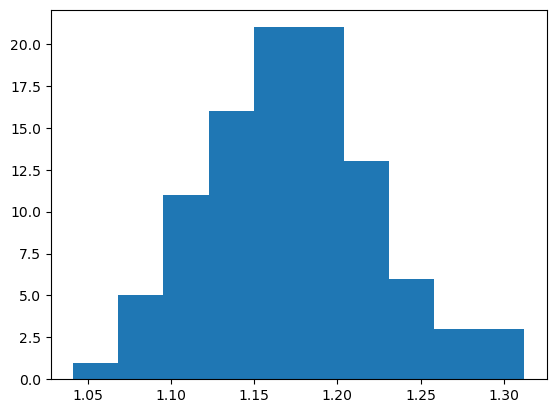

In [11]:
plt.hist(crps_samples[:, 0]/crps_samples[:, 1])

In [ ]:
bin_samples2 = bootstrap_bin(score_SSCrat_bin, (ensemble > 0).mean(axis=1), (Y.flatten() > 0).astype(int), 100,
                            scoring_rule=scoringrules.brier_score)

[Array(-4.1622343e-07, dtype=float32), Array(-9.803755e-06, dtype=float32)] -4.228829319871647 25.9581883258928
[Array(-0.0001764, dtype=float32), Array(-7.678993e-05, dtype=float32)] -0.7031838508069269 2.1488193381055845
[Array(-0.00040239, dtype=float32), Array(4.3252476e-05, dtype=float32)] -0.3778233856417728 3.4398593940031397
[Array(-3.5583973e-05, dtype=float32), Array(-1.6149412e-05, dtype=float32)] -0.4584923316892269 1.6276196694121137
[Array(1.1087395e-06, dtype=float32), Array(4.8419915e-05, dtype=float32)] -0.06345844224293823 3.891422116186323
[Array(-0.00013159, dtype=float32), Array(-7.058846e-05, dtype=float32)] -3.923285181538369 6.192974664035904
[Array(-6.1126348e-06, dtype=float32), Array(-4.6091372e-06, dtype=float32)] -65.15812912460989 95.59175521824767
[Array(6.9228496e-05, dtype=float32), Array(7.7693556e-05, dtype=float32)] -1.8495091506272965 3.426605561624441
[Array(-0.00053849, dtype=float32), Array(-0.00012351, dtype=float32)] -0.5665952593514629 2.48579

In [649]:
bin_samples = bootstrap_bin(score_SSCrat_bin, np.clip((ensemble > 0).mean(axis=1), 1e-2, 1 - 1e-2), (Y.flatten() > 0).astype(int), 120,
                            scoring_rule=scoringrules.log_score)

[Array(-0.00014772, dtype=float32), Array(-0.00022291, dtype=float32)] -0.689689521857857 2.005000721249543
[Array(8.839369e-05, dtype=float32), Array(3.336305e-05, dtype=float32)] -1.3525038358983448 2.643191069890568
[Array(9.924173e-05, dtype=float32), Array(-0.00021388, dtype=float32)] -0.4969972289155028 2.974677175824468
[Array(-1.9073486e-06, dtype=float32), Array(-1.5449255e-05, dtype=float32)] 0.4470433324132127 1.2083652783550567
[Array(-1.4230609e-05, dtype=float32), Array(-2.4865898e-05, dtype=float32)] -0.6632008118057524 2.111226805173149
[Array(-3.2037497e-07, dtype=float32), Array(1.2756902e-07, dtype=float32)] -1.025804807144164 1.9342067101143612
[Array(-5.0365925e-06, dtype=float32), Array(3.508591e-05, dtype=float32)] -2.2905029781225856 8.735843689490324
[Array(3.9368868e-05, dtype=float32), Array(-6.2147674e-06, dtype=float32)] 0.21797091211474545 1.6761568343881832
[Array(-0.00022297, dtype=float32), Array(0.00033821, dtype=float32)] -0.18838471354620973 1.755676

In [648]:
bin_samples[:, ]

array([[0.8989791 , 0.8608447 ],
       [0.8773683 , 0.25503674],
       [0.8966294 , 0.35534504],
       [0.9193733 , 0.7658092 ],
       [0.87712884, 0.9322195 ],
       [0.88355064, 0.9711656 ],
       [0.8939875 , 0.49831727],
       [0.91764766, 0.61298126],
       [0.92486405, 0.9178485 ],
       [0.86346596, 0.40094835],
       [0.8919436 , 0.7358537 ],
       [0.87493837, 0.85654026],
       [0.90573007, 0.84081256],
       [0.90191597, 0.58864987],
       [0.91605926, 0.76451325],
       [0.9113413 , 0.85692996],
       [0.90459025, 0.9635751 ],
       [0.92387986, 0.7838617 ],
       [0.8790223 , 0.7047394 ],
       [0.90350163, 0.8632432 ],
       [0.880921  , 0.6335798 ],
       [0.9018157 , 0.92614794],
       [0.9138336 , 0.77828294],
       [0.8506578 , 0.5057056 ],
       [0.8767192 , 0.81038374],
       [0.9053782 , 0.950577  ],
       [0.9115994 , 0.7279996 ],
       [0.89637387, 0.5405079 ],
       [0.9182184 , 0.5383215 ],
       [0.89990103, 0.6565011 ],
       [0.

In [323]:
mse_samples = bootstrap(score_SSCrat, ensemble, Y.flatten(), 100, scoring_rule=lambda y, X: (X.mean(axis=1 if len(X.shape) > 1 else 0) - y)**2)

7.892364102652817 5.746545829019573 0.09464821629266262 1.6212636152034103
1.3430068804217694
10.231404029675437 8.167901840540633 0.07160188781654997 1.5591879022159123
1.2361504467404003
14.427103396932493 11.389333017637352 0.29000561385491563 1.643311180179374
1.2342889497332692
14.1034103997114 10.675136340045698 0.1258283237389339 1.9460066230984336
1.3412370247455265
14.689130661684313 10.16928741613913 0.24105425777277398 2.0859667498481356
1.4553637464621594
10.75515262194759 7.863205697871939 0.07257867920652877 1.6348773897188584
1.4352007852804605
12.619574696690135 5.805336037479566 0.1505357905941128 2.3203764352182477
1.4995436841105652
12.371652882262795 9.61681038205204 0.22222222017451532 1.6393347012924053
1.2451815276864289
13.54877565969131 8.439504261494 0.1691919025147314 2.0293680277133244
1.552414441128121
18.45296094163694 11.851334829561425 0.30746706436304533 2.2975166984681232
1.4052920768739343
12.135598652822956 11.005017022622306 0.12717534728995916 1.37

In [264]:
score_SSCrat(ensemble, Y.flatten(), scoring_rule=lambda y, X: (X.mean(axis=1 if len(X.shape) > 1 else 0) - y)**2)

25.073069334228073 22.026774524698837 7.976545454581099e-11 1.895705631787399
1.4402194766227643


(np.float64(0.8302735461413145), np.float64(0.5764909860046196))

In [13]:
bin_samples_log = bootstrap_bin(score_SSCrat_bin, np.clip(((ensemble) > 0).mean(axis=1), 1e-2, 1 - 1e-2), (Y.flatten() > 0).astype(int), 100,
                             scoring_rule=scoringrules.log_score)

  0%|                                                   | 0/100 [00:00<?, ?it/s]

[Array(-0.00046444, dtype=float32), Array(0.0001862, dtype=float32)] -0.4420003816053944 1.9069042415871873


  2%|▊                                          | 2/100 [00:43<34:02, 20.84s/it]

[Array(-0.00105244, dtype=float32), Array(-0.00022411, dtype=float32)] -0.7329657935045036 3.203520655494017
[Array(-0.01134169, dtype=float32), Array(-0.0006448, dtype=float32)] -0.6481538513726844 1.956901160084873


  4%|█▋                                         | 4/100 [01:01<20:39, 12.92s/it]

...

[Array(1.5974045e-05, dtype=float32), Array(-8.46386e-06, dtype=float32)] 0.1574077838171482 1.7484001518009382


 99%|█████████████████████████████████████████▌| 99/100 [18:12<00:06,  6.05s/it]

[Array(-0.00389671, dtype=float32), Array(0.0002318, dtype=float32)] -0.16787602231420926 2.2202839499333535


100%|█████████████████████████████████████████| 100/100 [18:34<00:00, 11.14s/it]

[Array(-0.00118172, dtype=float32), Array(0.00018585, dtype=float32)] -0.5252185212918135 1.7444162118425353


In [24]:
score_SSCrat_bin(np.clip(((ensemble - Y.mean()) > 0).mean(axis=1), 1e-2, 1 - 1e-2), ((Y - Y.mean()).flatten() > 0).astype(int),
                             scoring_rule=scoringrules.log_score)

[Array(-3.361702e-05, dtype=float32), Array(-3.71933e-05, dtype=float32)] -0.32042550304011386 1.4883179827376005


(Array(0.90131605, dtype=float32), Array(0.8236736, dtype=float32))

In [35]:
np.quantile(crps_samples[:, 0]/crps_samples[:, 1], [0.025, 0.5, 0.975])

array([1.07529462, 1.1711092 , 1.28673666])

In [65]:
bin_samples_log2 = bootstrap_bin(score_SSCrat_bin, np.clip(((ensemble - Y.mean()) > 0).mean(axis=1), 1e-2, 1 - 1e-2), ((Y - Y.mean()).flatten() > 0).astype(int), 1,
                             scoring_rule=scoringrules.log_score)

100%|█████████████████████████████████████████████| 1/1 [00:04<00:00,  4.04s/it]

[Array(0.00207043, dtype=float32), Array(-0.00012785, dtype=float32)] -0.3933360437365855 1.126047011960482


In [14]:
samps = np.concatenate([bin_samples_log])
rats = samps[:, 0]/samps[:, 1]
rats = rats[rats > 0]

In [16]:
np.save("logs_samples_anomalous.npy", rats)

In [17]:
rats_normal = np.load("logs_samples_normal.npy")

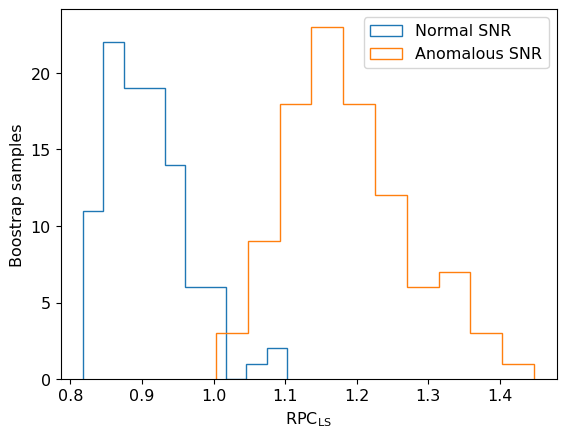

In [19]:
plt.rcParams.update({'font.size': 11.5})
plt.hist(rats_normal, histtype='step', label="Normal SNR")
plt.hist(rats, histtype='step', label="Anomalous SNR")
plt.xlabel(r"$\text{RPC}_\text{LS}$")
plt.ylabel("Boostrap samples")
plt.legend()
plt.savefig("hist_comp_log.pdf")

In [99]:
np.quantile(rats, [0.15, 0.85]), np.quantile(rats_normal, [0.15, 0.85])

(array([0.94276531, 1.3423191 ]), array([0.94686626, 1.25675201]))

In [82]:
sum(rats > 1)

np.int64(68)

In [265]:
mse_samples.mean(axis=0)

array([0.83408507, 0.61120658])

In [266]:
np.quantile(mse_samples[:, 0]/mse_samples[:, 1], 0.5)

np.float64(1.3773197376874409)

In [36]:
rpc_samples = bootstrap(classic_RPC, ensemble, (Y).flatten(), 100)

100%|███████████████████████████████████████| 100/100 [00:00<00:00, 5275.19it/s]


In [37]:
rpc_samples.mean()

np.float64(1.5484663588115763)

(array([ 4.,  4.,  3.,  8.,  7., 17., 23., 22.,  8.,  4.]),
 array([0.46990449, 0.6370428 , 0.8041811 , 0.9713194 , 1.1384577 ,
        1.305596  , 1.4727343 , 1.6398726 , 1.8070109 , 1.9741492 ,
        2.14128751]),
 <BarContainer object of 10 artists>)

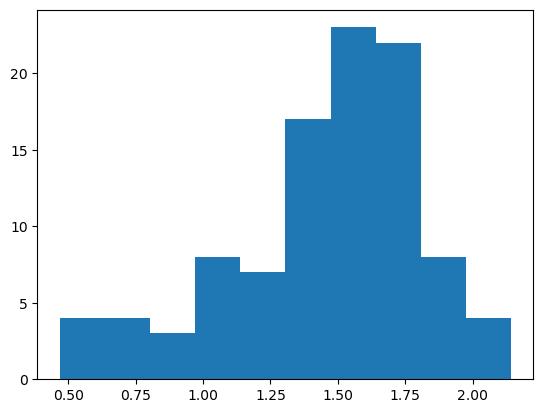

In [614]:
plt.hist(rpc_samples)

In [271]:
import matplotlib.pyplot as plt

In [577]:
np.quantile(crps_samples[:, 0]/crps_samples[:, 1], 0.14)

np.float32(1.0090802)

In [578]:
1 - 0.14

0.86

In [39]:
sum(crps_samples[:, 0]/crps_samples[:, 1] > 1)

np.int64(88)

In [36]:
bins = np.concat([bin_samples_log, bin_samples_log2])

In [37]:
rats = bins[:, 0]/bins[:, 1]
rats = rats[rats > 0]

In [38]:
sum(rats > 1)

np.int64(84)

In [583]:
np.save("Y.npy", Y)

In [584]:
np.save("ensemble.npy", ensemble)

In [603]:
(ensemble > 0).mean(axis=1), (Y.flatten() > 0).astype(int)

(array([0.36, 0.44, 0.72, 0.56, 0.24, 0.6 , 0.4 , 0.44, 0.2 , 0.64, 0.6 ,
        0.68, 0.6 , 0.36, 0.64, 0.2 , 0.04, 0.24, 0.32, 0.2 , 0.36, 0.36,
        0.44, 0.32, 0.48, 0.84, 0.32, 0.68, 0.48, 0.68, 0.72, 0.44, 0.68,
        0.08, 0.6 , 0.76, 0.32, 0.32, 0.56, 0.52, 0.56, 0.56, 0.44, 0.6 ,
        0.52, 0.44, 0.52, 0.48, 0.4 , 0.68, 0.12, 0.56, 0.56, 0.6 , 0.4 ,
        0.48, 0.72, 0.56, 0.48, 0.48, 0.68, 0.24, 0.44, 0.28, 0.32, 0.72,
        0.68, 0.56, 0.76, 0.6 , 0.52, 0.6 , 0.96, 0.64, 0.64, 0.56, 0.6 ,
        0.76, 0.6 , 0.48, 0.24, 0.6 , 0.44, 0.56, 0.32, 0.28, 0.76, 0.32,
        0.2 , 0.64, 0.48, 0.48, 0.84, 0.52, 0.32, 0.4 , 0.52, 0.52, 0.2 ,
        0.76]),
 array([1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
        1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
        0, 1, 0, 0, 1,

In [616]:
sum(rpc_samples > 1)

np.int64(86)

In [617]:
np.quantile(crps_samples[:, 0]/crps_samples[:, 1], 0.14)

np.float32(1.0090802)

In [642]:
np.quantile(rpc_samples, 0.14)

np.float64(1.0346937917319647)

In [639]:
np.nanquantile(bin_samples, 0.14)

np.float32(0.95589435)

In [633]:
bin_samples

array([1.332965  , 1.0794597 , 1.1556554 , 0.97476727, 1.3400923 ,
       1.0742335 , 1.1800922 , 1.0477768 , 1.7266792 , 1.4444155 ,
       1.3705097 , 1.2950054 , 0.9166116 , 0.939586  , 1.1035212 ,
       1.2638195 , 2.015505  , 0.9345003 , 1.8917699 , 1.094628  ,
       1.2759478 , 1.5546756 , 1.1346236 , 1.5313332 , 0.957083  ,
       0.        , 0.95283777, 1.0677445 , 1.445127  , 1.2310088 ,
       1.3584092 , 1.0300115 , 1.2906746 , 1.8436364 , 1.0421076 ,
       0.99840486, 1.2741356 , 0.99383104, 1.287423  , 0.94373894,
       0.98536134, 1.1463215 , 0.9355175 , 1.0352983 , 1.3930392 ,
       0.94924843, 1.1278759 , 0.        , 2.0929806 , 1.6396966 ,
       1.0813937 , 1.2316725 , 1.34867   , 1.0468167 , 0.9176292 ,
       1.477167  , 0.9776001 , 1.0673568 , 0.9164135 , 0.9381891 ,
       1.2569965 , 1.3107781 , 1.3555071 , 0.        , 1.0692276 ,
       1.2381252 , 0.        , 1.7882774 , 1.2778113 , 1.0018151 ,
       1.0886868 , 1.2350262 , 1.0392371 , 1.467757  , 0.99061

In [637]:
len(bin_samples[bin_samples > 1])

76

In [638]:
76/95

0.8

In [646]:
score_SSCrat_bin(np.clip((ensemble > 0).mean(axis=1), 1e-2, 1 - 1e-2), (Y.flatten() > 0).astype(int),
                            scoring_rule=scoringrules.log_score)

[Array(-0.00171685, dtype=float32), Array(0.00146818, dtype=float32)] -0.2755388978361114 1.8401747953635204


(Array(0.8989842, dtype=float32), Array(0.7702633, dtype=float32))